# **dataset creation**

In [21]:
pip install pyrosm pandas networkx openpyxl shapely geopandas pyogrio

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 21.2 MB/s eta 0:00:00
  Installing build dependencies ... canceled
ERROR: Operation cancelled by user


In [ ]:
!pip install -q pyrosm pandas pyarrow

from pathlib import Path
import gc
import pandas as pd
from pyrosm import OSM

# =========================
# CONFIG
# =========================
PBF_PATH = Path("tunisia-260409.osm.pbf")
OUT_DIR = Path("tunisia_tiles")
OUT_DIR.mkdir(exist_ok=True)

# Approx Tunisia bbox:
# [min_lon, min_lat, max_lon, max_lat]
TUNISIA_BBOX = [7.5, 30.0, 11.7, 37.6]

# Tile size in degrees
LON_STEP = 0.8
LAT_STEP = 0.8

HIGHWAY_SPEED = {
    "motorway": 110,
    "motorway_link": 60,
    "trunk": 100,
    "trunk_link": 50,
    "primary": 80,
    "primary_link": 45,
    "secondary": 60,
    "secondary_link": 40,
    "tertiary": 50,
    "tertiary_link": 35,
    "unclassified": 35,
    "residential": 30,
    "living_street": 15,
    "service": 20,
    "road": 30,
}

KEEP_HIGHWAYS = {
    "motorway", "motorway_link",
    "trunk", "trunk_link",
    "primary", "primary_link",
    "secondary", "secondary_link",
    "tertiary", "tertiary_link",
    "unclassified", "residential", "service", "road"
}

# =========================
# HELPERS
# =========================
def norm_speed(value, highway):
    if pd.isna(value):
        return HIGHWAY_SPEED.get(str(highway), 40)

    if isinstance(value, list) and len(value) > 0:
        value = value[0]

    s = str(value)
    digits = "".join(ch for ch in s if ch.isdigit())

    if digits:
        return max(10, min(130, int(digits)))

    return HIGHWAY_SPEED.get(str(highway), 40)


def make_tiles(bbox, lon_step, lat_step):
    min_lon, min_lat, max_lon, max_lat = bbox
    tiles = []

    lon = min_lon
    tile_id = 1
    while lon < max_lon:
        next_lon = min(lon + lon_step, max_lon)

        lat = min_lat
        while lat < max_lat:
            next_lat = min(lat + lat_step, max_lat)
            tiles.append({
                "tile_id": tile_id,
                "bbox": [lon, lat, next_lon, next_lat]
            })
            tile_id += 1
            lat = next_lat

        lon = next_lon

    return tiles


def validate_tile(nodes, edges):
    required_node_cols = {"node_id", "longitude", "latitude"}
    required_edge_cols = {
        "edge_id", "osm_way_id", "from_node", "to_node",
        "street_name", "road_type", "length_m", "speed_kmh", "travel_time_min"
    }

    missing_nodes = required_node_cols - set(nodes.columns)
    missing_edges = required_edge_cols - set(edges.columns)

    if missing_nodes:
        raise ValueError(f"Missing node columns: {missing_nodes}")
    if missing_edges:
        raise ValueError(f"Missing edge columns: {missing_edges}")

    if len(nodes) == 0:
        raise ValueError("Nodes table is empty")
    if len(edges) == 0:
        raise ValueError("Edges table is empty")

    if nodes["node_id"].isna().any():
        raise ValueError("Null node_id found")
    if edges["from_node"].isna().any() or edges["to_node"].isna().any():
        raise ValueError("Null from_node/to_node found")

    if (edges["length_m"] < 0).any():
        raise ValueError("Negative edge length found")

    if (edges["travel_time_min"] < 0).any():
        raise ValueError("Negative travel time found")


def process_tile(pbf_path, bbox, tile_id):
    print(f"\n=== Tile {tile_id} | bbox={bbox} ===")

    osm = OSM(str(pbf_path), bounding_box=bbox)
    nodes, edges = osm.get_network(network_type="driving", nodes=True)

    if nodes is None or edges is None or len(nodes) == 0 or len(edges) == 0:
        print("No data in this tile.")
        return None

    # Keep only useful columns
    node_cols = [c for c in ["id", "lon", "lat"] if c in nodes.columns]
    edge_cols = [c for c in ["u", "v", "id", "name", "highway", "oneway", "maxspeed", "length"] if c in edges.columns]

    nodes = nodes[node_cols].copy()
    edges = edges[edge_cols].copy()

    nodes = nodes.rename(columns={
        "id": "node_id",
        "lon": "longitude",
        "lat": "latitude",
    })

    edges = edges.rename(columns={
        "u": "from_node",
        "v": "to_node",
        "id": "osm_way_id",
    })

    # Filter road types
    edges["road_type"] = edges["highway"].astype(str)
    edges = edges[edges["road_type"].isin(KEEP_HIGHWAYS)].copy()

    if len(edges) == 0:
        print("No usable roads after filtering.")
        return None

    edges["street_name"] = edges["name"].fillna("Unnamed road")
    edges["length_m"] = pd.to_numeric(edges["length"], errors="coerce").fillna(0.0)
    edges["speed_kmh"] = [
        norm_speed(ms, hw) for ms, hw in zip(edges.get("maxspeed"), edges["road_type"])
    ]
    edges["speed_kmh"] = pd.to_numeric(edges["speed_kmh"], errors="coerce").fillna(40).clip(lower=10)
    edges["travel_time_min"] = (edges["length_m"] / 1000.0) / edges["speed_kmh"] * 60.0

    # Lightweight integer ids per tile
    edges = edges.reset_index(drop=True)
    edges["edge_id"] = [f"{tile_id}_{i+1}" for i in range(len(edges))]

    # Keep only nodes referenced by edges
    used_nodes = set(edges["from_node"]).union(set(edges["to_node"]))
    nodes = nodes[nodes["node_id"].isin(used_nodes)].copy()

    if len(nodes) == 0:
        print("No referenced nodes left.")
        return None

    # Final columns
    nodes = nodes[["node_id", "longitude", "latitude"]].drop_duplicates()
    edges = edges[
        ["edge_id", "osm_way_id", "from_node", "to_node", "street_name",
         "road_type", "oneway", "length_m", "speed_kmh", "travel_time_min"]
    ].drop_duplicates()

    validate_tile(nodes, edges)

    node_path = OUT_DIR / f"nodes_tile_{tile_id:03d}.parquet"
    edge_path = OUT_DIR / f"edges_tile_{tile_id:03d}.parquet"

    nodes.to_parquet(node_path, index=False)
    edges.to_parquet(edge_path, index=False)

    summary = {
        "tile_id": tile_id,
        "bbox": str(bbox),
        "nodes_count": int(len(nodes)),
        "edges_count": int(len(edges)),
        "nodes_file": str(node_path),
        "edges_file": str(edge_path),
    }

    print(f"Saved nodes={len(nodes):,}, edges={len(edges):,}")
    return summary


# =========================
# RUN ALL TILES
# =========================
if not PBF_PATH.exists():
    raise FileNotFoundError(f"PBF file not found: {PBF_PATH}")

tiles = make_tiles(TUNISIA_BBOX, LON_STEP, LAT_STEP)
print(f"Total tiles: {len(tiles)}")

summaries = []

for tile in tiles:
    try:
        result = process_tile(PBF_PATH, tile["bbox"], tile["tile_id"])
        if result is not None:
            summaries.append(result)
    except Exception as e:
        print(f"Tile {tile['tile_id']} failed: {e}")
    finally:
        gc.collect()

summary_df = pd.DataFrame(summaries)
summary_df.to_csv(OUT_DIR / "tile_summary.csv", index=False)

print("\nDONE")
print(summary_df.head())
print(f"\nProcessed tiles with data: {len(summary_df)}")
print(f"Total nodes across tiles: {summary_df['nodes_count'].sum():,}")
print(f"Total edges across tiles: {summary_df['edges_count'].sum():,}")

Total tiles: 60

=== Tile 1 | bbox=[7.5, 30.0, 8.3, 30.8] ===


/usr/local/lib/python3.12/dist-packages/pyrosm/pyrosm.py:249: UserWarning: Could not find any edges for given area.
  edges, node_gdf = get_network_data(


No data in this tile.

=== Tile 2 | bbox=[7.5, 30.8, 8.3, 31.6] ===
Tile 2 failed: "None of ['id'] are in the columns"

=== Tile 3 | bbox=[7.5, 31.6, 8.3, 32.4] ===
Tile 3 failed: 'name'

=== Tile 4 | bbox=[7.5, 32.4, 8.3, 33.199999999999996] ===
Tile 4 failed: 'name'

=== Tile 5 | bbox=[7.5, 33.199999999999996, 8.3, 33.99999999999999] ===
Saved nodes=20,101, edges=22,532

=== Tile 6 | bbox=[7.5, 33.99999999999999, 8.3, 34.79999999999999] ===
Saved nodes=33,124, edges=34,775

=== Tile 7 | bbox=[7.5, 34.79999999999999, 8.3, 35.59999999999999] ===
Saved nodes=1,314, edges=1,328

=== Tile 8 | bbox=[7.5, 35.59999999999999, 8.3, 36.399999999999984] ===
Tile 8 failed: 'NoneType' object is not iterable

=== Tile 9 | bbox=[7.5, 36.399999999999984, 8.3, 37.19999999999998] ===
Tile 9 failed: 'name'

=== Tile 10 | bbox=[7.5, 37.19999999999998, 8.3, 37.6] ===


/usr/local/lib/python3.12/dist-packages/pyrosm/pyrosm.py:249: UserWarning: Could not find any edges for given area.
  edges, node_gdf = get_network_data(


No data in this tile.

=== Tile 11 | bbox=[8.3, 30.0, 9.100000000000001, 30.8] ===


...

No data in this tile.

=== Tile 57 | bbox=[11.500000000000004, 34.79999999999999, 11.7, 35.59999999999999] ===


/usr/local/lib/python3.12/dist-packages/pyrosm/pyrosm.py:249: UserWarning: Could not find any edges for given area.
  edges, node_gdf = get_network_data(


No data in this tile.

=== Tile 58 | bbox=[11.500000000000004, 35.59999999999999, 11.7, 36.399999999999984] ===
Tile 58 failed: "None of ['id'] are in the columns"

=== Tile 59 | bbox=[11.500000000000004, 36.399999999999984, 11.7, 37.19999999999998] ===


/usr/local/lib/python3.12/dist-packages/pyrosm/pyrosm.py:249: UserWarning: Could not find any edges for given area.
  edges, node_gdf = get_network_data(


No data in this tile.

=== Tile 60 | bbox=[11.500000000000004, 37.19999999999998, 11.7, 37.6] ===
Tile 60 failed: "None of ['id'] are in the columns"

DONE
   tile_id                                               bbox  nodes_count  \
0        5  [7.5, 33.199999999999996, 8.3, 33.99999999999999]        20101   
1        6   [7.5, 33.99999999999999, 8.3, 34.79999999999999]        33124   
2        7   [7.5, 34.79999999999999, 8.3, 35.59999999999999]         1314   
3       15  [8.3, 33.199999999999996, 9.100000000000001, 3...        36134   
4       16  [8.3, 33.99999999999999, 9.100000000000001, 34...       152160   

   edges_count                            nodes_file  \
0        22532  tunisia_tiles/nodes_tile_005.parquet   
1        34775  tunisia_tiles/nodes_tile_006.parquet   
2         1328  tunisia_tiles/nodes_tile_007.parquet   
3        41396  tunisia_tiles/nodes_tile_015.parquet   
4       157738  tunisia_tiles/nodes_tile_016.parquet   

                             edges_fil

In [ ]:
import pandas as pd
from pathlib import Path

DATA_DIR = Path("tunisia_tiles")
edge_files = sorted(DATA_DIR.glob("edges_tile_*.parquet"))

bad_files = []

for i, f in enumerate(edge_files, 1):
    try:
        df = pd.read_parquet(f)
        print(f"[OK] {i}/{len(edge_files)} -> {f.name} | rows={len(df)}")
    except Exception as e:
        print(f"[BAD] {i}/{len(edge_files)} -> {f.name} | error={e}")
        bad_files.append(str(f))

print("\nBad files:")
print(bad_files)

[BAD] 1/30 -> edges_tile_005.parquet | error=Could not open Parquet input source '<Buffer>': Couldn't deserialize thrift: TProtocolException: Invalid data

[OK] 2/30 -> edges_tile_006.parquet | rows=34775
[OK] 3/30 -> edges_tile_007.parquet | rows=1328
[OK] 4/30 -> edges_tile_015.parquet | rows=41396
[OK] 5/30 -> edges_tile_016.parquet | rows=157738
[OK] 6/30 -> edges_tile_017.parquet | rows=233013
[OK] 7/30 -> edges_tile_018.parquet | rows=277164
[OK] 8/30 -> edges_tile_019.parquet | rows=325118
[BAD] 9/30 -> edges_tile_025.parquet | error=Could not open Parquet input source '<Buffer>': Couldn't deserialize thrift: don't know what type: 

[OK] 10/30 -> edges_tile_026.parquet | rows=138058
[OK] 11/30 -> edges_tile_027.parquet | rows=382607
[OK] 12/30 -> edges_tile_028.parquet | rows=301164
[OK] 13/30 -> edges_tile_029.parquet | rows=342954
[OK] 14/30 -> edges_tile_030.parquet | rows=43043
[OK] 15/30 -> edges_tile_033.parquet | rows=16313
[OK] 16/30 -> edges_tile_034.parquet | rows=8568

In [20]:
import gc
import pandas as pd
from pathlib import Path
from pyrosm import OSM

PBF_PATH = Path("tunisia-260409.osm.pbf")
OUT_DIR = Path("tunisia_tiles")
OUT_DIR.mkdir(exist_ok=True)

HIGHWAY_SPEED = {
    "motorway": 110,
    "motorway_link": 60,
    "trunk": 100,
    "trunk_link": 50,
    "primary": 80,
    "primary_link": 45,
    "secondary": 60,
    "secondary_link": 40,
    "tertiary": 50,
    "tertiary_link": 35,
    "unclassified": 35,
    "residential": 30,
    "living_street": 15,
    "service": 20,
    "road": 30,
}

KEEP_HIGHWAYS = {
    "motorway", "motorway_link",
    "trunk", "trunk_link",
    "primary", "primary_link",
    "secondary", "secondary_link",
    "tertiary", "tertiary_link",
    "unclassified", "residential", "service", "road"
}

TUNISIA_BBOX = [7.5, 30.0, 11.7, 37.6]
LON_STEP = 0.8
LAT_STEP = 0.8


def norm_speed(value, highway):
    if pd.isna(value):
        return HIGHWAY_SPEED.get(str(highway), 40)
    if isinstance(value, list) and len(value) > 0:
        value = value[0]
    s = str(value)
    digits = "".join(ch for ch in s if ch.isdigit())
    if digits:
        return max(10, min(130, int(digits)))
    return HIGHWAY_SPEED.get(str(highway), 40)


def make_tiles(bbox, lon_step, lat_step):
    min_lon, min_lat, max_lon, max_lat = bbox
    tiles = []
    lon = min_lon
    tile_id = 1

    while lon < max_lon:
        next_lon = min(lon + lon_step, max_lon)
        lat = min_lat

        while lat < max_lat:
            next_lat = min(lat + lat_step, max_lat)
            tiles.append({
                "tile_id": tile_id,
                "bbox": [lon, lat, next_lon, next_lat]
            })
            tile_id += 1
            lat = next_lat

        lon = next_lon

    return tiles


def rebuild_one_tile(tile_id):
    tiles = make_tiles(TUNISIA_BBOX, LON_STEP, LAT_STEP)
    tile = next(t for t in tiles if t["tile_id"] == tile_id)
    bbox = tile["bbox"]

    print(f"\nRebuilding tile {tile_id} with bbox={bbox}")

    osm = OSM(str(PBF_PATH), bounding_box=bbox)
    nodes, edges = osm.get_network(network_type="driving", nodes=True)

    if nodes is None or edges is None or len(nodes) == 0 or len(edges) == 0:
        print(f"Tile {tile_id}: no data")
        return

    nodes = nodes[[c for c in ["id", "lon", "lat"] if c in nodes.columns]].copy()
    edges = edges[[c for c in ["u", "v", "id", "name", "highway", "oneway", "maxspeed", "length"] if c in edges.columns]].copy()

    nodes = nodes.rename(columns={
        "id": "node_id",
        "lon": "longitude",
        "lat": "latitude",
    })

    edges = edges.rename(columns={
        "u": "from_node",
        "v": "to_node",
        "id": "osm_way_id",
    })

    edges["road_type"] = edges["highway"].astype(str)
    edges = edges[edges["road_type"].isin(KEEP_HIGHWAYS)].copy()

    if len(edges) == 0:
        print(f"Tile {tile_id}: no usable roads after filtering")
        return

    edges["street_name"] = edges["name"].fillna("Unnamed road")
    edges["length_m"] = pd.to_numeric(edges["length"], errors="coerce").fillna(0.0)
    edges["speed_kmh"] = [
        norm_speed(ms, hw) for ms, hw in zip(edges.get("maxspeed"), edges["road_type"])
    ]
    edges["speed_kmh"] = pd.to_numeric(edges["speed_kmh"], errors="coerce").fillna(40).clip(lower=10)
    edges["travel_time_min"] = (edges["length_m"] / 1000.0) / edges["speed_kmh"] * 60.0

    used_nodes = set(edges["from_node"]).union(set(edges["to_node"]))
    nodes = nodes[nodes["node_id"].isin(used_nodes)].copy()

    nodes = nodes[["node_id", "longitude", "latitude"]].drop_duplicates()
    edges = edges[
        ["osm_way_id", "from_node", "to_node", "street_name",
         "road_type", "oneway", "length_m", "speed_kmh", "travel_time_min"]
    ].drop_duplicates()

    # overwrite the corrupted files cleanly
    edge_path = OUT_DIR / f"edges_tile_{tile_id:03d}.parquet"
    if edge_path.exists():
        edge_path.unlink()

    edges.to_parquet(edge_path, index=False)

    print(f"Saved: {edge_path}")
    print(f"Rows: {len(edges):,}")

    del nodes, edges
    gc.collect()


rebuild_one_tile(5)
rebuild_one_tile(25)

print("\nDone rebuilding bad tiles.")

ModuleNotFoundError: No module named 'pyrosm'

In [ ]:
import pandas as pd

for f in [
    "tunisia_tiles/edges_tile_005.parquet",
    "tunisia_tiles/edges_tile_025.parquet",
]:
    df = pd.read_parquet(f)
    print(f, "->", len(df), "rows")

tunisia_tiles/edges_tile_005.parquet -> 22532 rows
tunisia_tiles/edges_tile_025.parquet -> 24896 rows


In [ ]:
import pandas as pd
from pathlib import Path
import gc

DATA_DIR = Path("tunisia_tiles")
OUT_DIR = Path("tunisia_merged")
OUT_DIR.mkdir(exist_ok=True)

node_files = sorted(DATA_DIR.glob("nodes_tile_*.parquet"))
edge_files = sorted(DATA_DIR.glob("edges_tile_*.parquet"))

# nodes
nodes_parts = []
for i, f in enumerate(node_files, 1):
    print(f"[Nodes] {i}/{len(node_files)} -> {f.name}")
    df = pd.read_parquet(f)
    df = df[["node_id", "longitude", "latitude"]].drop_duplicates()
    nodes_parts.append(df)

nodes = pd.concat(nodes_parts, ignore_index=True)
print("Nodes before dedup:", len(nodes))
nodes = nodes.drop_duplicates(subset=["node_id"])
print("Nodes after dedup:", len(nodes))

del nodes_parts
gc.collect()

# edges
edges_parts = []
for i, f in enumerate(edge_files, 1):
    print(f"[Edges] {i}/{len(edge_files)} -> {f.name}")
    df = pd.read_parquet(f)

    keep_cols = [
        "osm_way_id", "from_node", "to_node", "street_name",
        "road_type", "oneway", "length_m", "speed_kmh", "travel_time_min"
    ]
    df = df[keep_cols].drop_duplicates()
    edges_parts.append(df)

edges = pd.concat(edges_parts, ignore_index=True)
print("Edges before dedup:", len(edges))
edges = edges.drop_duplicates(subset=["osm_way_id", "from_node", "to_node"])
print("Edges after dedup:", len(edges))

valid_nodes = set(nodes["node_id"])
edges = edges[
    edges["from_node"].isin(valid_nodes) &
    edges["to_node"].isin(valid_nodes)
].copy()

print("Edges after node validation:", len(edges))

nodes.to_parquet(OUT_DIR / "tunisia_nodes_FINAL.parquet", index=False)
edges.to_parquet(OUT_DIR / "tunisia_edges_FINAL.parquet", index=False)

print("\nDONE")
print("Final nodes:", len(nodes))
print("Final edges:", len(edges))

[Nodes] 1/30 -> nodes_tile_005.parquet
[Nodes] 2/30 -> nodes_tile_006.parquet
[Nodes] 3/30 -> nodes_tile_007.parquet
[Nodes] 4/30 -> nodes_tile_015.parquet
[Nodes] 5/30 -> nodes_tile_016.parquet
[Nodes] 6/30 -> nodes_tile_017.parquet
[Nodes] 7/30 -> nodes_tile_018.parquet
[Nodes] 8/30 -> nodes_tile_019.parquet
[Nodes] 9/30 -> nodes_tile_025.parquet
[Nodes] 10/30 -> nodes_tile_026.parquet
[Nodes] 11/30 -> nodes_tile_027.parquet
[Nodes] 12/30 -> nodes_tile_028.parquet
[Nodes] 13/30 -> nodes_tile_029.parquet
[Nodes] 14/30 -> nodes_tile_030.parquet
[Nodes] 15/30 -> nodes_tile_033.parquet
[Nodes] 16/30 -> nodes_tile_034.parquet
[Nodes] 17/30 -> nodes_tile_035.parquet
[Nodes] 18/30 -> nodes_tile_036.parquet
[Nodes] 19/30 -> nodes_tile_037.parquet
[Nodes] 20/30 -> nodes_tile_038.parquet
[Nodes] 21/30 -> nodes_tile_039.parquet
[Nodes] 22/30 -> nodes_tile_040.parquet
[Nodes] 23/30 -> nodes_tile_043.parquet
[Nodes] 24/30 -> nodes_tile_044.parquet
[Nodes] 25/30 -> nodes_tile_045.parquet
[Nodes] 2

In [ ]:
import pandas as pd

nodes = pd.read_parquet("tunisia_merged/tunisia_nodes_FINAL.parquet")
edges = pd.read_parquet("tunisia_merged/tunisia_edges_FINAL.parquet")

print(nodes.head())
print(edges.head())

print("Nodes:", len(nodes))
print("Edges:", len(edges))

print("\nNulls in nodes:")
print(nodes.isna().sum())

print("\nNulls in edges:")
print(edges.isna().sum())

      node_id  longitude   latitude
0  2590984659   7.888726  33.872139
1  3471923761   7.888770  33.872383
2  6663124942   7.888775  33.872498
3   295901408   7.888772  33.872612
4  2589853881   7.888772  33.872665
   osm_way_id   from_node     to_node   street_name    road_type oneway  \
0    26995985  2590984659  3471923761  Unnamed road     tertiary    yes   
1    26995985  3471923761  6663124942  Unnamed road     tertiary    yes   
2    26995985  6663124942   295901408  Unnamed road     tertiary    yes   
3    26995985   295901408  2589853881  Unnamed road     tertiary    yes   
4    26995987   295901429  2590983713  Unnamed road  residential   None   

   length_m  speed_kmh  travel_time_min  
0    27.448         50         0.032938  
1    12.733         50         0.015280  
2    12.729         50         0.015275  
3     5.938         50         0.007126  
4    11.961         30         0.023922  
Nodes: 5042009
Edges: 5236974

Nulls in nodes:
node_id      0
longitude    0
lati

In [ ]:
edges["oneway"] = edges["oneway"].fillna("no")

In [19]:
!pip install -q openpyxl pyarrow pandas

import pandas as pd
from pathlib import Path

# Paths
NODES_PATH = Path("tunisia_merged/tunisia_nodes_FINAL.parquet")
EDGES_PATH = Path("tunisia_merged/tunisia_edges_FINAL.parquet")
OUTPUT_XLSX = Path("tunisia_dataset.xlsx")

# Load
print("Loading nodes...")
nodes = pd.read_parquet(NODES_PATH)

print("Loading edges...")
edges = pd.read_parquet(EDGES_PATH)

print("Nodes loaded:", len(nodes))
print("Edges loaded:", len(edges))

# Excel row limit safety
MAX_ROWS_PER_SHEET = 1_000_000

with pd.ExcelWriter(OUTPUT_XLSX, engine="openpyxl") as writer:
    # Metadata sheet
    meta = pd.DataFrame([
        {"field": "dataset", "value": "Tunisia road network"},
        {"field": "nodes_rows", "value": len(nodes)},
        {"field": "edges_rows", "value": len(edges)},
        {"field": "nodes_source", "value": str(NODES_PATH)},
        {"field": "edges_source", "value": str(EDGES_PATH)},
    ])
    meta.to_excel(writer, sheet_name="metadata", index=False)

    # Nodes sheets
    print("\nWriting nodes sheets...")
    for i in range(0, len(nodes), MAX_ROWS_PER_SHEET):
        chunk = nodes.iloc[i:i + MAX_ROWS_PER_SHEET]
        sheet_name = f"nodes_{i // MAX_ROWS_PER_SHEET + 1}"
        print(" ->", sheet_name, "| rows:", len(chunk))
        chunk.to_excel(writer, sheet_name=sheet_name, index=False)

    # Edges sheets
    print("\nWriting edges sheets...")
    for i in range(0, len(edges), MAX_ROWS_PER_SHEET):
        chunk = edges.iloc[i:i + MAX_ROWS_PER_SHEET]
        sheet_name = f"edges_{i // MAX_ROWS_PER_SHEET + 1}"
        print(" ->", sheet_name, "| rows:", len(chunk))
        chunk.to_excel(writer, sheet_name=sheet_name, index=False)

print("\nDONE")
print("Created file:", OUTPUT_XLSX)

Loading nodes...


FileNotFoundError: [Errno 2] No such file or directory: 'tunisia_merged/tunisia_nodes_FINAL.parquet'

In [ ]:
# =========================
# 1) Install
# =========================
!pip install -q pandas pyarrow

# =========================
# 2) Imports
# =========================
import pandas as pd
from pathlib import Path

# =========================
# 3) Paths
# =========================
NODES_PATH = Path("tunisia_merged/tunisia_nodes_FINAL.parquet")
EDGES_PATH = Path("tunisia_merged/tunisia_edges_FINAL.parquet")

OUTPUT_FILE = "tunisia_dataset_light.csv"

# =========================
# 4) Load data
# =========================
print("Loading nodes...")
nodes = pd.read_parquet(NODES_PATH)

print("Loading edges...")
edges = pd.read_parquet(EDGES_PATH)

print("Nodes:", len(nodes))
print("Edges:", len(edges))

# =========================
# 5) Sample (LIGHT)
# =========================
SAMPLE_SIZE = 300_000

print(f"\nSampling {SAMPLE_SIZE} edges...")

edges_sample = edges.sample(
    n=min(SAMPLE_SIZE, len(edges)),
    random_state=42
)

# =========================
# 6) Clean
# =========================
edges_sample["oneway"] = edges_sample["oneway"].fillna("no")

# =========================
# 7) Merge nodes → edges
# =========================
print("\nMerging node coordinates...")

# Rename nodes for join
nodes_from = nodes.rename(columns={
    "node_id": "from_node",
    "longitude": "from_lon",
    "latitude": "from_lat"
})

nodes_to = nodes.rename(columns={
    "node_id": "to_node",
    "longitude": "to_lon",
    "latitude": "to_lat"
})

# Merge
df = edges_sample.merge(nodes_from, on="from_node", how="left")
df = df.merge(nodes_to, on="to_node", how="left")

# =========================
# 8) Final columns
# =========================
df = df[
    [
        "osm_way_id",
        "street_name",
        "road_type",
        "oneway",
        "length_m",
        "speed_kmh",
        "travel_time_min",
        "from_node",
        "to_node",
        "from_lat",
        "from_lon",
        "to_lat",
        "to_lon",
    ]
]

print("Final dataset size:", len(df))

# =========================
# 9) Save CSV
# =========================
print("\nSaving CSV...")

df.to_csv(OUTPUT_FILE, index=False)

print("\n✅ DONE")
print("Created:", OUTPUT_FILE)

Loading nodes...
Loading edges...
Nodes: 5042009
Edges: 5236974

Sampling 300000 edges...

Merging node coordinates...
Final dataset size: 300000

Saving CSV...

✅ DONE
Created: tunisia_dataset_light.csv


# **ML**

### **Section 1 — Load and inspect data**

In [15]:
df.columns
df.head()
df.dtypes

,0
osm_way_id,int64
street_name,object
road_type,object
oneway,object
length_m,float64
speed_kmh,float64
travel_time_min,float64
from_node,float64
to_node,float64
from_lat,float64


### **Section 2 — Cleaning and preprocessing**

### **Section 3 — Correlation matrix and PCA**

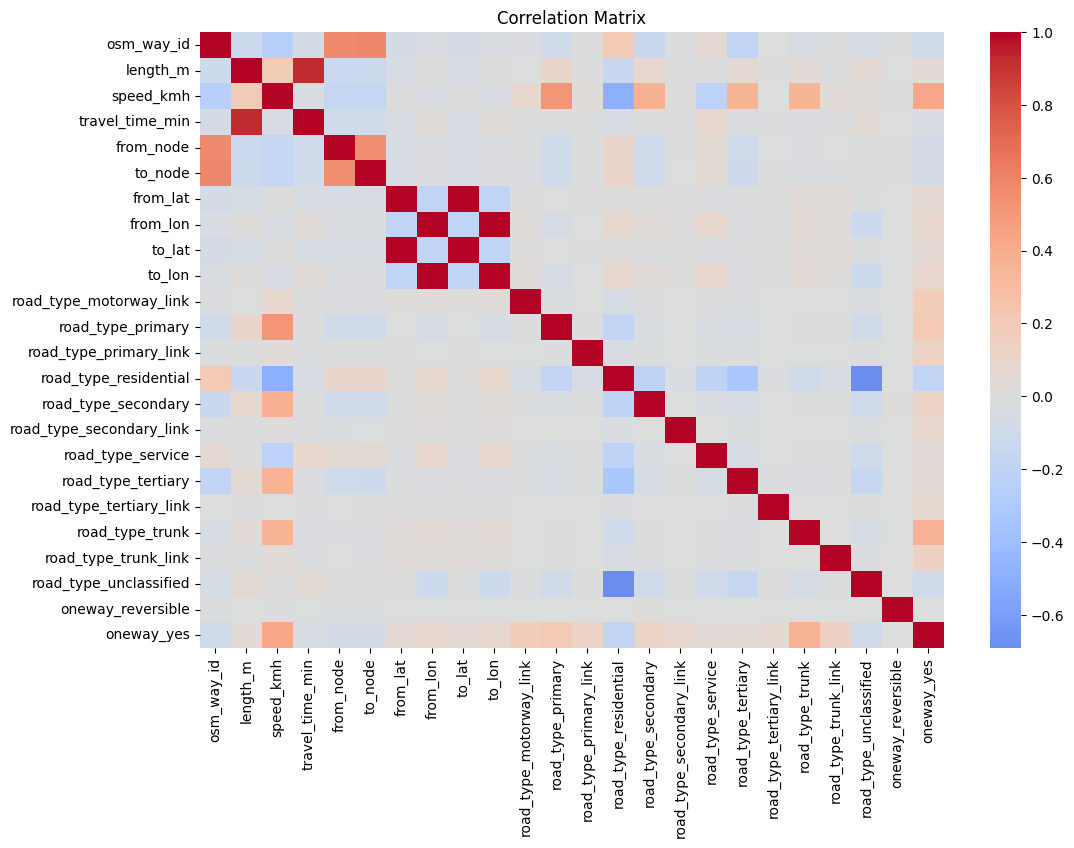

In [22]:
# =========================
# 1) Imports
# =========================
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# =========================
# 2) Load dataset
# =========================
df = pd.read_csv("/content/tunisia_dataset_light.csv")

# =========================
# 3) Clean
# =========================
df["oneway"] = df["oneway"].fillna("no")

# Encode categorical
df_encoded = pd.get_dummies(df, columns=["road_type", "oneway"], drop_first=True)

# =========================
# 4) REMOVE NON-NUMERIC
# =========================
df_encoded = df_encoded.drop(columns=["street_name"])

# =========================
# 5) Correlation Matrix
# =========================
plt.figure(figsize=(12, 8))

corr = df_encoded.corr()

sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()

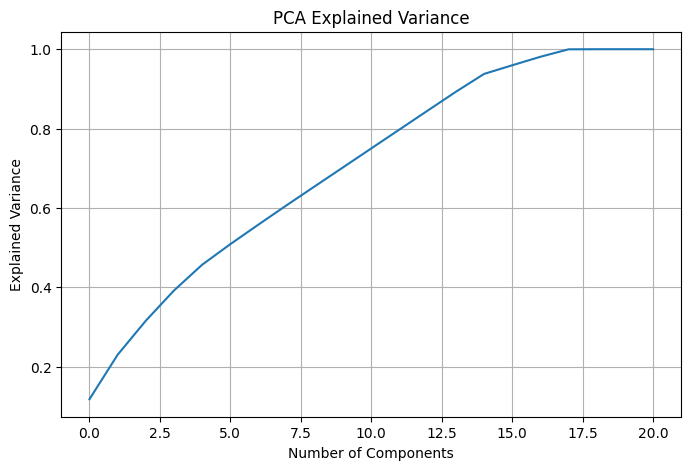

In [23]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA   # ← Add this line
# =========================
# 5) PCA
# =========================
X = df_encoded.drop(columns=["travel_time_min", "length_m", "speed_kmh"])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Explained variance
plt.figure(figsize=(8,5))
plt.plot(pca.explained_variance_ratio_.cumsum())
plt.xlabel("Number of Components")
plt.ylabel("Explained Variance")
plt.title("PCA Explained Variance")
plt.grid()
plt.show()

### **Section 4 — Feature/target selection**

In [24]:
!pip install -q xgboost
from xgboost import XGBRegressor

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# =========================
# Prepare data
# =========================
X = df_encoded.drop(columns=[
    "speed_kmh",
    "travel_time_min",
    "street_name",
    "osm_way_id",
    "from_node",
    "to_node"
], errors="ignore")
y = df_encoded["speed_kmh"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================
# Models
# =========================
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "XGBoost": XGBRegressor(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )
}

results = {}

# =========================
# Training
# =========================
for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)

    results[name] = r2
    print(f"{name} R²: {r2}")

# =========================
# Results
# =========================
print("\nFinal Results:")
for k, v in results.items():
    print(k, ":", v)


Training Linear Regression...
Linear Regression R²: 0.929779519256884

Training Ridge...
Ridge R²: 0.9297798192414456

Training Decision Tree...
Decision Tree R²: 0.9497514188901552

Training Random Forest...
Random Forest R²: 0.9683188934503197

Training Gradient Boosting...
Gradient Boosting R²: 0.9044638891957626

Training XGBoost...
XGBoost R²: 0.9436514377593994

Final Results:
Linear Regression : 0.929779519256884
Ridge : 0.9297798192414456
Decision Tree : 0.9497514188901552
Random Forest : 0.9683188934503197
Gradient Boosting : 0.9044638891957626
XGBoost : 0.9436514377593994


In [12]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Training Random Forest...
Random Forest R²: 0.9683188934503197

Feature Importance:
                     feature  importance
6          road_type_primary    0.267084
11         road_type_service    0.223142
8      road_type_residential    0.177236
16    road_type_unclassified    0.129390
12        road_type_tertiary    0.052825
9        road_type_secondary    0.031125
0                   length_m    0.027009
14           road_type_trunk    0.015933
1                   from_lat    0.015712
3                     to_lat    0.015131
2                   from_lon    0.014916
4                     to_lon    0.013822
5    road_type_motorway_link    0.005081
18                oneway_yes    0.003985
15      road_type_trunk_link    0.003662
7     road_type_primary_link    0.002303
10  road_type_secondary_link    0.000828
13   road_type_tertiary_link    0.000817
17         oneway_reversible    0.000000


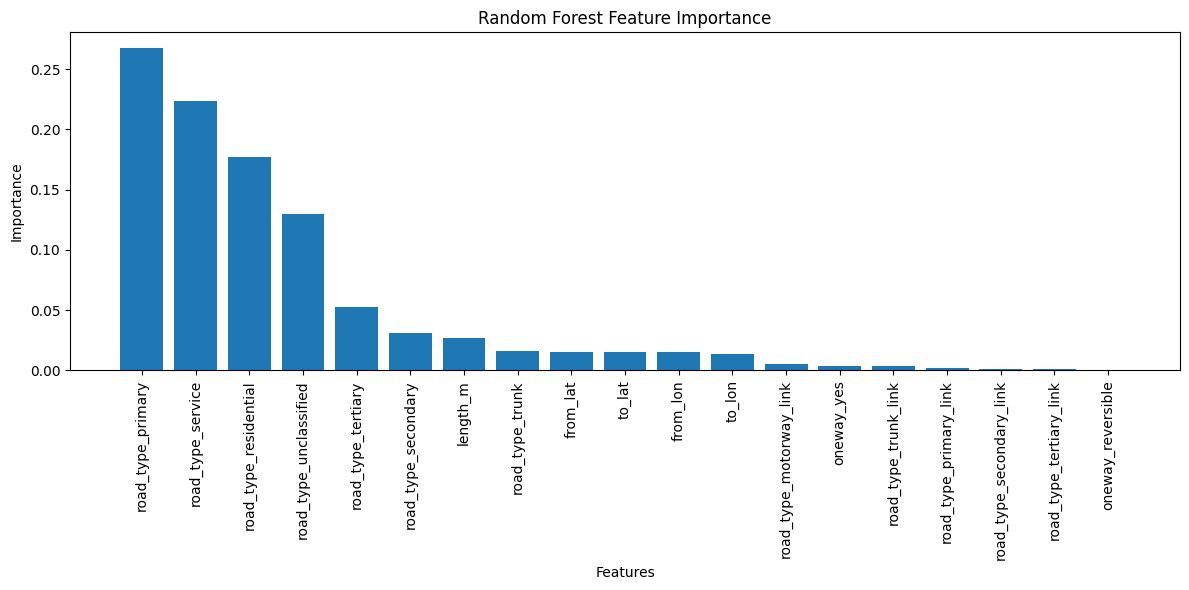

In [25]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# =========================
# Train Random Forest only
# =========================
rf_model = RandomForestRegressor(
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)

print("Training Random Forest...")
rf_model.fit(X_train, y_train)

# Prediction
y_pred = rf_model.predict(X_test)
r2 = r2_score(y_test, y_pred)

print("Random Forest R²:", r2)

# =========================
# Feature Importance
# =========================
importances = rf_model.feature_importances_
feature_names = X_train.columns

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

print("\nFeature Importance:")
print(importance_df)

# =========================
# Plot Feature Importance
# =========================
plt.figure(figsize=(12, 6))
plt.bar(importance_df["feature"], importance_df["importance"])
plt.xticks(rotation=90)
plt.title("Random Forest Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

### **Section 5 — Baseline models comparison**

In [ ]:
'Gradient boosting'

### **Section 6 — Hyperparameter tuning**

In [26]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# =========================
# Define parameter space
# =========================
param_dist = {
    "n_estimators": [100, 200, 300],
    "max_depth": [10, 20, 30, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

# =========================
# Randomized Search
# =========================
rf = RandomForestRegressor(random_state=42)

search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=15,              # number of combinations tested
    cv=3,
    scoring="r2",
    n_jobs=-1,
    random_state=42,
    verbose=2
)

print("Tuning Random Forest...")
search.fit(X_train, y_train)

# =========================
# Best model
# =========================
best_model = search.best_estimator_

print("\nBest Parameters:")
print(search.best_params_)

print("\nBest CV Score:")
print(search.best_score_)

# =========================
# Evaluate on test set
# =========================
y_pred = best_model.predict(X_test)
final_r2 = r2_score(y_test, y_pred)

print("\nFinal R² after tuning:", final_r2)

Tuning Random Forest...
Fitting 3 folds for each of 15 candidates, totalling 45 fits

Best Parameters:
{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}

Best CV Score:
0.9630921858405045

Final R² after tuning: 0.968657947511101


### **Section 7 — Final evaluation**

In [28]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 0.3006808333333334


In [29]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

RMSE: 2.0791292498303227


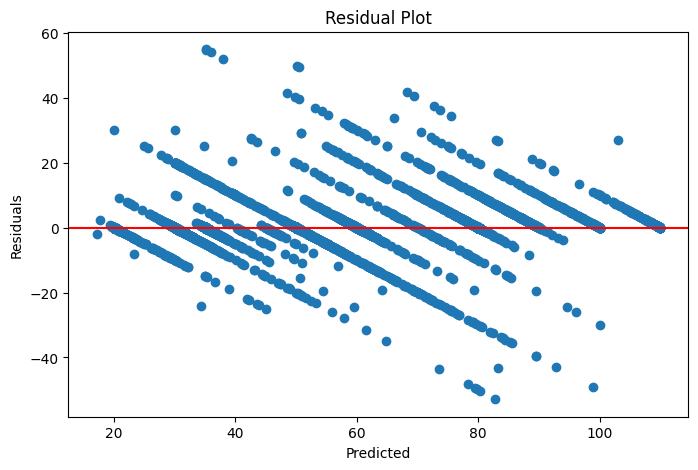

In [30]:
import matplotlib.pyplot as plt

residuals = y_test - y_pred

plt.figure(figsize=(8,5))
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='r')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

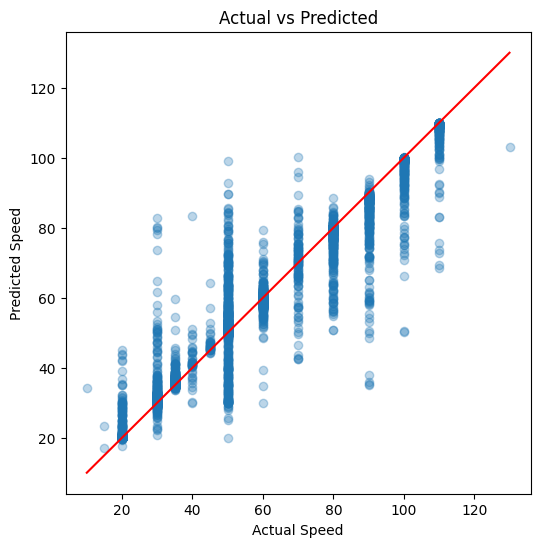

In [31]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.xlabel("Actual Speed")
plt.ylabel("Predicted Speed")
plt.title("Actual vs Predicted")

# perfect line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.show()

### **Section 8 — Export model to .pkl**

In [27]:
import joblib

joblib.dump(best_model, "best_speed_model.pkl")

print("✅ Model saved successfully!")

✅ Model saved successfully!
